### **Triển khai mội ví dụ của Bounding Box Detection sử dụng thư viên PyTorch**
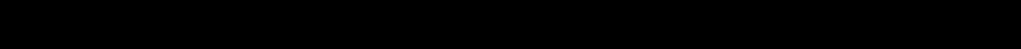
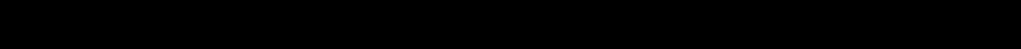

**1. Khai báo các thư viện cần thiết**

In [1]:
import torch
import torchvision
from torchvision import transforms as T
import cv2

**2. Tải mô hình pretrained**


-Tải mô hình pre-trained SSD300_VGG16, mô hình được thiets kế cho các nhiệm vụ phát hện đối tượng


In [2]:
model = torchvision.models.detection.ssd300_vgg16
weights = torchvision.models.detection.SSD300_VGG16_Weights.DEFAULT
model = model(weights=weights)
model.eval()

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

**3. Đọc tên các lớp**

- Đọc tên các lớp được ghi trong file "classes.txt" và thêm vào danh sách classnames
- File "classes.txt" có dạng:

car

dog

cat

...

nên sử dụng mothod splitlines() để tách các dòng chứa tên 1 class

In [3]:
classnames = []
with open('classes.txt', 'r') as f:
    classnames = f.read().splitlines()

**4. Đọc và tiền xử lý hình ảnh**

- Hàm load_image có chức năng đọc ảnh từ file bằng thư viện cv2 và trả về numpy array
- Hàm transform_image chuyển ảnh sang Tensor để model xử lý

In [4]:
def load_image(image_path):
    image = cv2.imread(image_path)
    return image

def transform_image(image):
    img_transform = T.ToTensor()
    image_tensor = img_transform(image)
    return image_tensor

**5. Tiến hành dự đoán**

- Hàm detect_objects dùng một mô hình phát hiện đối tượng pre-trained, một tensor ảnh đầu vào và ngưỡng tin cậy
- torch.no_grad() tắt gradient vì chỉ predict chứ không train -> giúp chạy nhanh hơn
- y_pred = model([image_tensor]) cho mô hình dự đoán
- bbox, scores, labels dữ liệu sau khi train
- indices là mảng các index có score > ngưỡng tin cậy
- filtered_box, filtered_scores, filtered_labels là các kết quả được lọc theo indices

In [24]:
def detect_objects(model, image_tensor, confidence_threshold=0.8):
    with torch.no_grad():
        y_pred = model([image_tensor])

    bbox, scores, labels = y_pred[0]['boxes'], y_pred[0]['scores'], y_pred[0]['labels']
    indices = torch.nonzero(scores > confidence_threshold).squeeze(1)
    filtered_box = bbox[indices]
    filtered_scores = scores[indices]
    filtered_labels = labels[indices]

    return filtered_box, filtered_scores, filtered_labels


**6. Vẽ các Bounding Box**

- x, y, w, h là tọa độ của các bounding box
- c2v.rectangle() vẽ các bounding box trên ảnh với tọa độ đã có, color (0, 0, 255), thinkness(5)
- lấy class_index và tìm tên class_detected
- hiển thị cả điểm dự đoán của class bên cạnh box
- c2v.putText vẽ text lên ảnh bao gồm: tên class và score

In [25]:
def draw_boxes_and_labels(image, bbox, scores, labels, class_names):
    img_copy = image.copy()

    for i in range(len(bbox)):
        x, y, w, h = bbox[i].numpy().astype(int)
        cv2.rectangle(img_copy, (x, y), (w, h), (0, 0, 255), 5)

        class_index = labels[i].numpy().astype(int)
        class_detected = class_names[class_index - 1]
        score = scores[i].item()
        text = f"{class_detected} {score:.2f}"
        cv2.putText(img_copy, text, (x, y + 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 2, cv2.LINE_AA)

    return img_copy

**7. Hiển thị kết quả**
- lấy ảnh và load_image -> chuyển img sang tensor
- gọi hàm detect_objects để lấy các dữ liệu bbox, scores, labels
- vẽ bounding box, labels, score bằng draw_boxes_and_labels
- dùng thư viện matplotlib để hiển thị ảnh kết quả

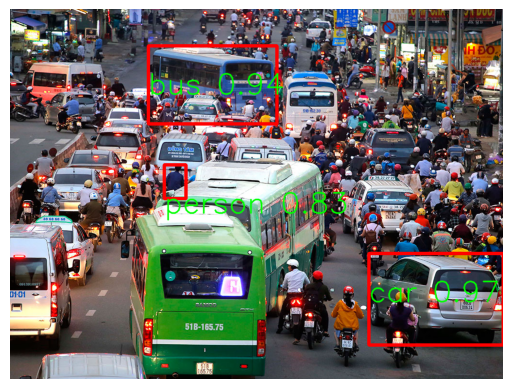

In [28]:
import matplotlib.pyplot as plt

image_path = 'img_1.png'
img = load_image(image_path)

img_tensor = transform_image(img)

bbox, scores, labels = detect_objects(model, img_tensor)

result_img = draw_boxes_and_labels(img, bbox, scores, labels, classnames)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()